In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')
sns.set()
%matplotlib inline
!pip install -q gdown
import gdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
url = "https://drive.google.com/uc?id=1QtQuR2nEPtiruWbJ_FIFDPrlauS1ukAN"
output = "indian_liver_patient.csv"
gdown.download(url, output, quiet=False)
df = pd.read_csv(output)

Downloading...
From: https://drive.google.com/uc?id=1QtQuR2nEPtiruWbJ_FIFDPrlauS1ukAN
To: /content/indian_liver_patient.csv
100%|██████████| 23.9k/23.9k [00:00<00:00, 8.78MB/s]


In [ ]:
print(df.head())

   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_and_Globulin_Ratio  Dataset  
0      3.3                        0.90        1 

In [ ]:
print(df.shape)

(583, 11)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
None


In [ ]:
print(df.describe())

              Age  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
count  583.000000       583.000000        583.000000            583.000000   
mean    44.746141         3.298799          1.486106            290.576329   
std     16.189833         6.209522          2.808498            242.937989   
min      4.000000         0.400000          0.100000             63.000000   
25%     33.000000         0.800000          0.200000            175.500000   
50%     45.000000         1.000000          0.300000            208.000000   
75%     58.000000         2.600000          1.300000            298.000000   
max     90.000000        75.000000         19.700000           2110.000000   

       Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
count                583.000000                  583.000000      583.000000   
mean                  80.713551                  109.910806        6.483190   
std                  182.620356                  288.918529 

In [ ]:
print(df.isnull().sum())

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64


In [ ]:
if df["Albumin_and_Globulin_Ratio"].isnull().sum() > 0:
    df["Albumin_and_Globulin_Ratio"].fillna(
        df["Albumin_and_Globulin_Ratio"].median(),
        inplace=True
    )

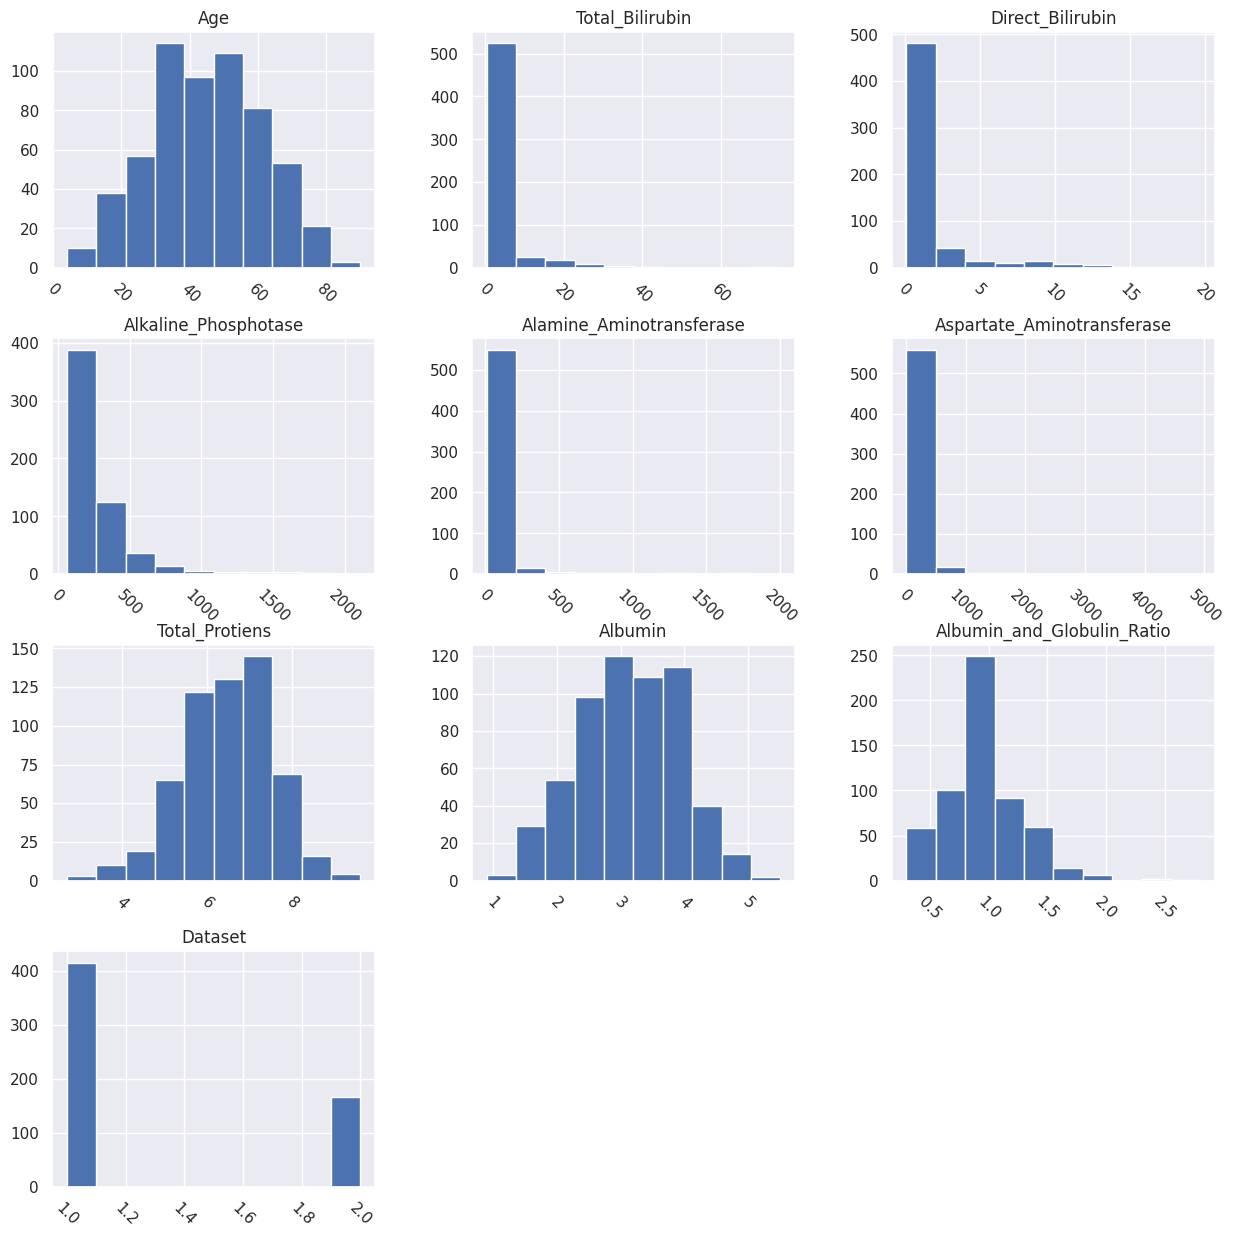

In [ ]:

df.hist(figsize=(15,15), xrot=-45, bins=10)
plt.show()

In [ ]:

def convertdataset(x):
    if x == 2:
        return 0
    return 1
df['Dataset'] = df['Dataset'].map(convertdataset)

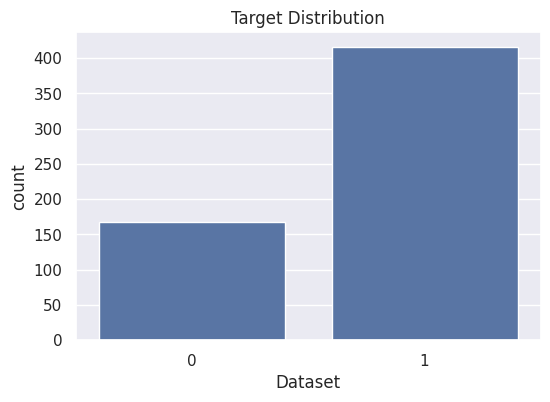

In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(x="Dataset", data=df)
plt.title("Target Distribution")
plt.show()

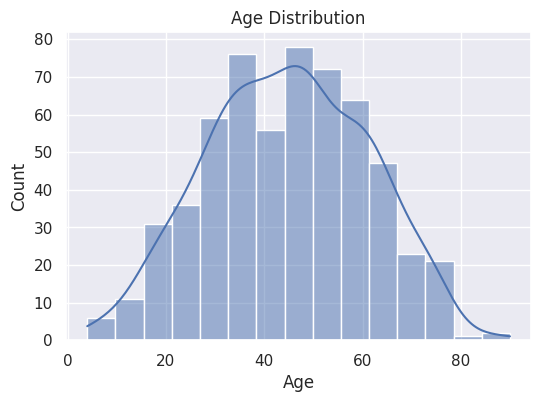

In [ ]:

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

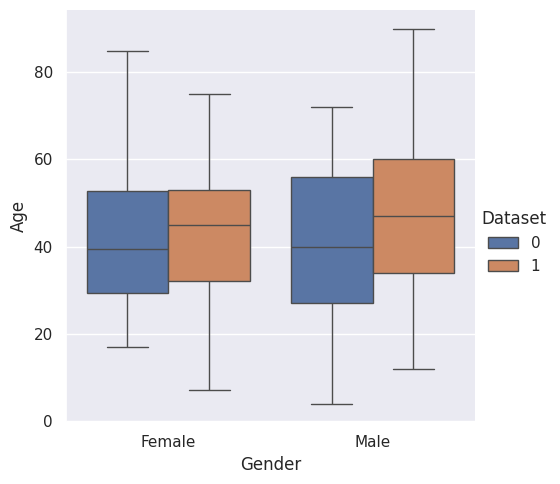

In [ ]:
sns.catplot(x="Gender", y="Age", hue="Dataset", kind="box", data=df)

In [ ]:

def convertgender(x):
    if x == 'Male':
        return 0
    else:
        return 1
df['Gender'] = df['Gender'].map(convertgender)

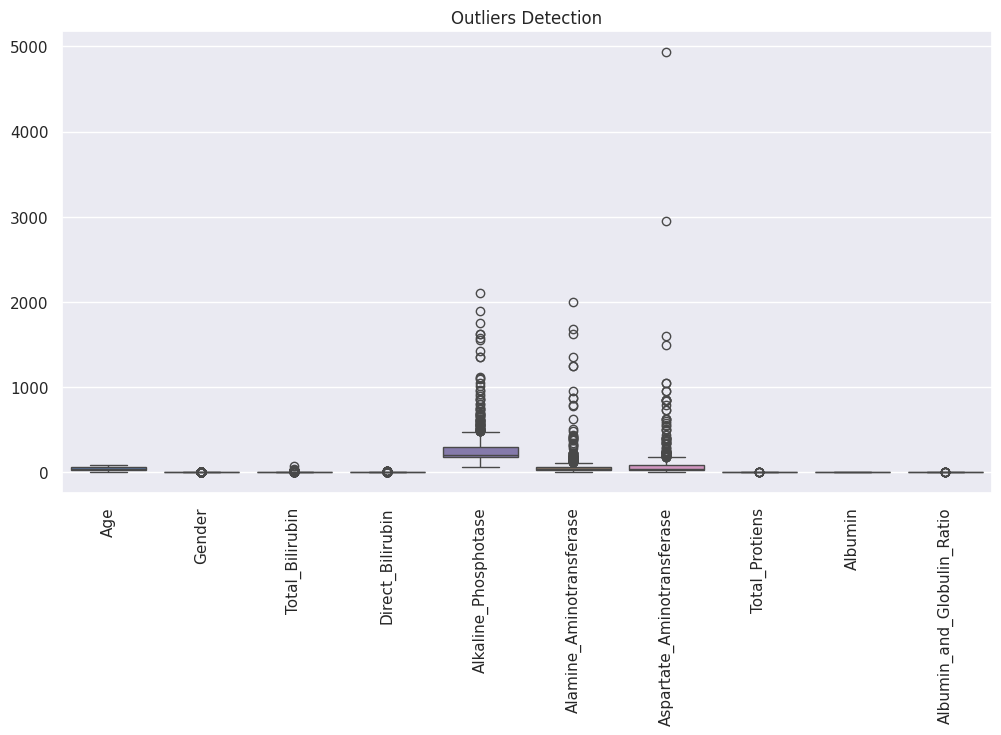

In [ ]:

plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("Dataset", axis=1))
plt.xticks(rotation=90)
plt.title("Outliers Detection")
plt.show()

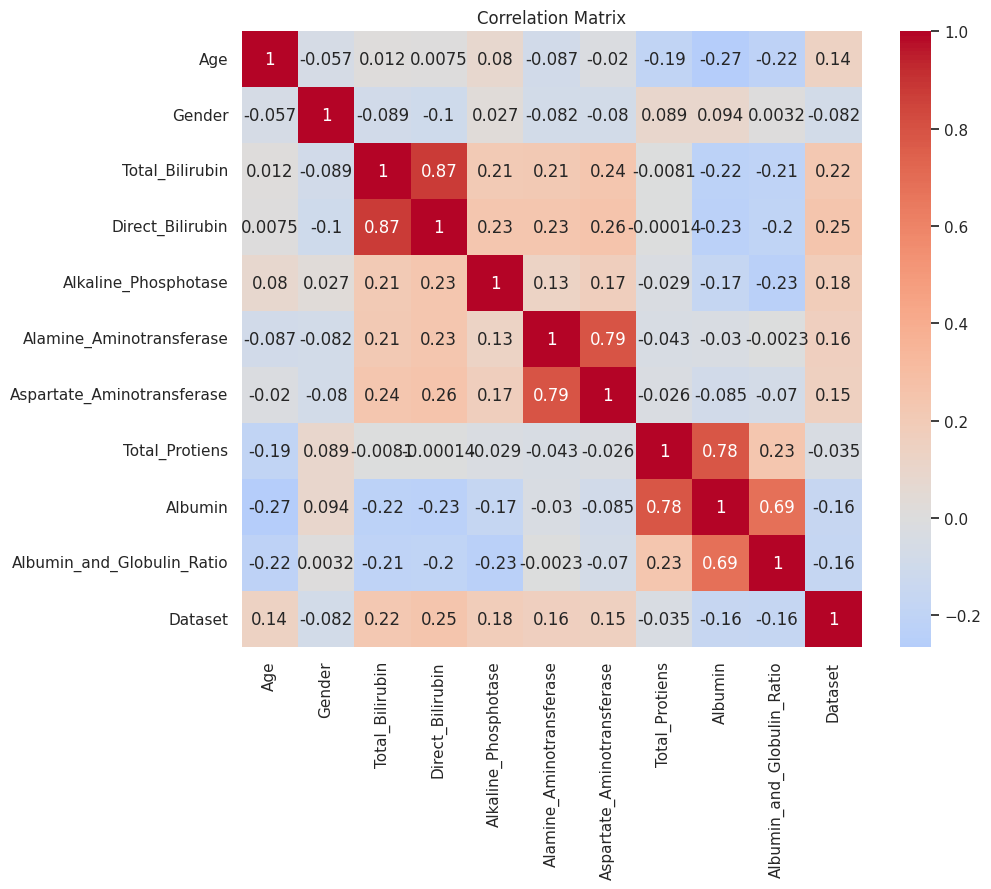

In [ ]:

plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

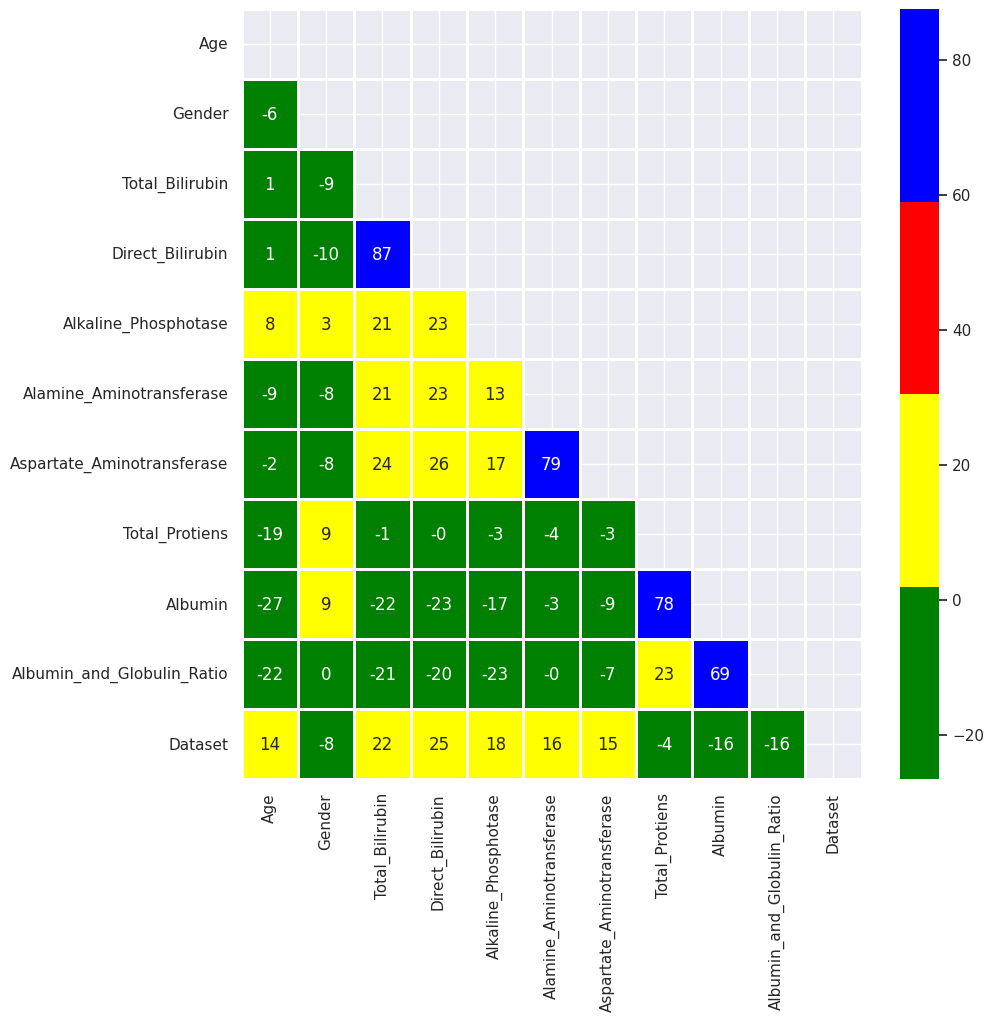

In [ ]:

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(10,10))
sns.heatmap(corr*100, mask=mask, fmt=".0f", annot=True, lw=1, cmap=ListedColormap(['green','yellow','red','blue']))
plt.show()

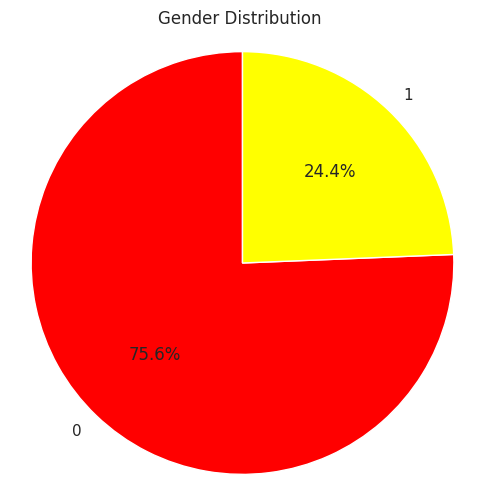

In [ ]:

gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'yellow'])
plt.title("Gender Distribution ")
plt.axis('equal')
plt.show()

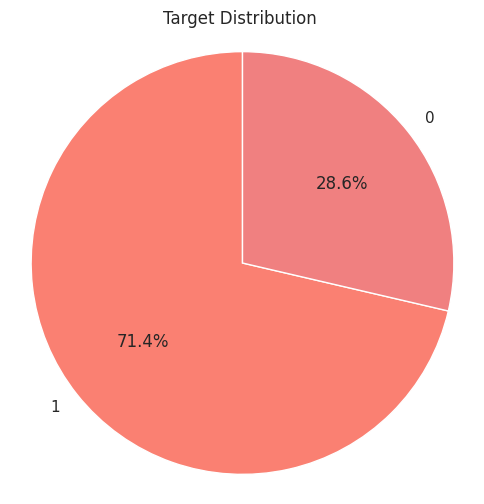

In [ ]:

target_counts = df['Dataset'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90, colors=['salmon', 'lightcoral'])
plt.title("Target Distribution ")
plt.axis('equal')
plt.show()

In [ ]:

grouped = df.groupby("Dataset").mean()
print("\nAverage Feature Values by Target:")
print(grouped)


Average Feature Values by Target:
               Age    Gender  Total_Bilirubin  Direct_Bilirubin  \
Dataset                                                           
0        41.239521  0.299401         1.142515          0.396407   
1        46.153846  0.221154         4.164423          1.923558   

         Alkaline_Phosphotase  Alamine_Aminotransferase  \
Dataset                                                   
0                  219.754491                 33.652695   
1                  319.007212                 99.605769   

         Aspartate_Aminotransferase  Total_Protiens   Albumin  \
Dataset                                                         
0                         40.688623        6.543114  3.344311   
1                        137.699519        6.459135  3.060577   

         Albumin_and_Globulin_Ratio  
Dataset                              
0                          1.028383  
1                          0.914255  


In [ ]:

df = df.drop_duplicates()
df = df[df.Aspartate_Aminotransferase <= 3000]
df = df.dropna(how='any')
print("\nCleaned Dataset Shape:")
print(df.shape)
print(df.head())


Cleaned Dataset Shape:
(569, 11)
   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65       1              0.7               0.1                   187   
1   62       0             10.9               5.5                   699   
2   62       0              7.3               4.1                   490   
3   58       0              1.0               0.4                   182   
4   72       0              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_and_Globulin_Ratio  Dataset  
0      3.3    

In [ ]:

X = df.drop("Dataset", axis=1)
y = df["Dataset"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}


Logistic Regression Accuracy: 0.7368
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.21      0.32        33
           1       0.75      0.95      0.84        81

    accuracy                           0.74       114
   macro avg       0.69      0.58      0.58       114
weighted avg       0.72      0.74      0.69       114



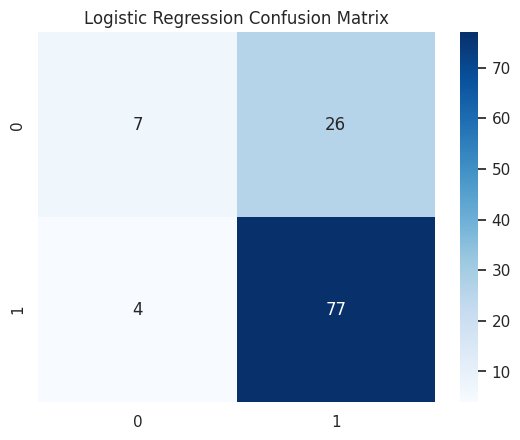


Random Forest Accuracy: 0.6842
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.18      0.25        33
           1       0.73      0.89      0.80        81

    accuracy                           0.68       114
   macro avg       0.56      0.54      0.53       114
weighted avg       0.63      0.68      0.64       114



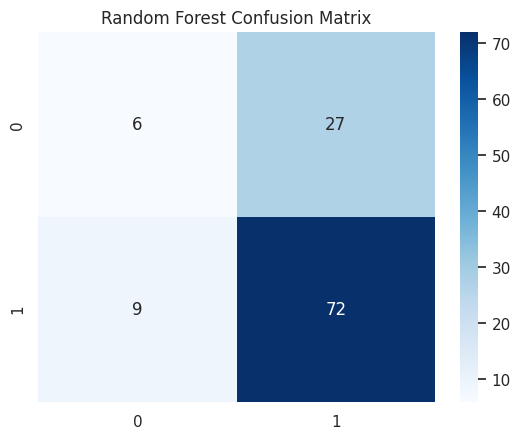


SVM Accuracy: 0.7105
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.71      1.00      0.83        81

    accuracy                           0.71       114
   macro avg       0.36      0.50      0.42       114
weighted avg       0.50      0.71      0.59       114



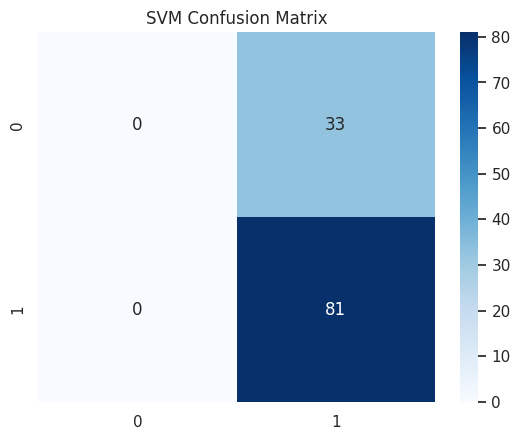

In [ ]:

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()